This notebook is used for testing the training of the integrated flow and transport model

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import jax
import jax.numpy as jnp
import jax.tree_util as jtu

import equinox as eqx 

import optax

from DiffFlowTransport.transport import SASTransport
from DiffFlowTransport.flow import LSTM
# from DiffFlowTransport.sas import SAS_Gamma, SAS_Uniform, SAS_Gamma_VaryingScale
# from DiffFlowTransport.sas import SAS_NormalMDN, SAS_GammaMDN
from DiffFlowTransport.sas import initialize_sas_model
from DiffFlowTransport.utils import scale_df, make_pytorch_timeseries_dataloader
from DiffFlowTransport.utils.plot import plot_timeseries_obs_1to1, plot_PQET_quantile
from DiffFlowTransport.utils.plot import plot_PQET_ST, plot_PQET_ST2, plot_young_water
from DiffFlowTransport.utils import train_flow_model, train_transport_model, mse, predict_dl
from DiffFlowTransport.model import load_model, save_model

import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
# %reload_ext autoreload


# Read the data

In [2]:
f_data = './data_withDiffusion.csv'
df = pd.read_csv(f_data, index_col=0)
df.index = pd.to_datetime(df.index)
df.head()

,J,SNOW,SM,P,P2,ET,Q,C_J,C_P,C_P2,C_Q
2012-10-01,0.0,0.0,0.0,0.0,0.0,0.112503,0.000000,0.0,0.0,0.0,0.0
2012-10-02,0.0,0.0,0.0,0.0,0.0,0.319922,0.000083,0.0,0.0,0.0,0.0
2012-10-03,0.0,0.0,0.0,0.0,0.0,0.165604,0.000030,0.0,0.0,0.0,0.0
2012-10-04,0.0,0.0,0.0,0.0,0.0,0.027064,0.000057,0.0,0.0,0.0,0.0
2012-10-05,0.0,0.0,0.0,0.0,0.0,0.033552,0.000100,0.0,0.0,0.0,0.0


In [3]:
def get_fluxes_from_df_OakCreek1(df, nτ=None):
    # J = jnp.array(df['J'].values)
    # C_J = jnp.array(df[['C_J']].values)
    J = jnp.array(df['P2'].values)
    C_J = jnp.array(df[['C_P2']].values)
    Q = jnp.array(df['Q'].values)
    ET = jnp.array(df['ET'].values)
    C_Q_J = jnp.array(df['C_Q'].values)

    # sTmT initial conditions
    if nτ is None:
        sTmT_init = jnp.zeros([J.size, 2])
    else:
        sTmT_init = jnp.zeros([nτ, 2])
    return J, Q, ET, C_J, C_Q_J, sTmT_init

J, Q, ET, C_J, C_Q_J, sTmT_init = get_fluxes_from_df_OakCreek1(df)


INFO:2025-03-02 11:41:58,355:jax._src.xla_bridge:945: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2025-03-02 11:41:58,355 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2025-03-02 11:41:58,357:jax._src.xla_bridge:945: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-03-02 11:41:58,357 - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


# Parameters

In [4]:
# The flow and transport model coupling type
flow_transport_coupling_type = 0

# Watershed
watershed_name = 'OakCreek'

# Label
# model_label = 'invariant-gamma'

# Skip the first several days
cutoff_length = 0


## Transport model configuration

In [5]:
# Number of SAS inputs depends on the coupling type
if flow_transport_coupling_type == 0:
    n_sas_input = 1

elif flow_transport_coupling_type == 1:
    n_sas_input = flow_params['n_hidden']

elif flow_transport_coupling_type == 2:
    n_sas_input = flow_params['n_hidden'] + 1

else:
    n_sas_input = 1
    

In [6]:
transport_params = {
    "transport_specs": {
        "dt": 1.,
        "α_Q": 1.,
        "α_ET": 0.,
        "k1": [0.],
        "C_eq": [0.],
        "C_Q_old": [0.],
        # "C_Q_old": [np.mean(C_J[:cutoff_length] * J[:cutoff_length]) / Q[:cutoff_length].mean()]
    },
    "sas_specs": {
        "Q SAS fun": {
            # "func": "Gamma",
            # "args": {
            #     "scale": 4000.0,
            #     "a": 0.5
            # }
            "func": "NormalMDN",
            "args": {
                "scale": 4000.0,
                "n_input": n_sas_input,  # Same as the number of hidden states used in the flow LSTM model
                "n_hidden": 10,
                "n_mixture": 5,
                "key": 42,
                "width_size": 10,
                "depth": 2
            }
        },
        "ET SAS fun": {
            "func": "Uniform",
            "args": {
                "scale": 400.0
            }
        }
    }
}


## Training configuration and dataloader

In [7]:
train_config = {
    "learning_rate": 0.01,
    # "epochs": 200,
    "epochs": 10,
    "train_start": '2015-10-01',
    "train_end": '2020-09-30',
    "test_start": '2021-10-01',
    "test_end": '2023-12-28',
    "scaler_type": "minmax"
}


# Initialize the transport models

In [8]:
# The transport model
sas_Q = initialize_sas_model(transport_params["sas_specs"]["Q SAS fun"])
sas_ET = initialize_sas_model(transport_params["sas_specs"]["ET SAS fun"])
transport_model = SASTransport(sas_Q, sas_ET, **transport_params["transport_specs"])


# Prepare optimizer and training data

## The training/test time

In [9]:
train_start, train_end = train_config['train_start'], train_config['train_end']
test_start, test_end = train_config['test_start'], train_config['test_end']

train_start_ind = df.index.get_loc(train_start)
train_end_ind = df.index.get_loc(train_end)
test_start_ind = df.index.get_loc(test_start)
test_end_ind = df.index.get_loc(test_end)


## Optimizer

In [10]:
optim = optax.adamw(train_config["learning_rate"])


# The transport model

## Get the transport model training data

In [11]:
# TODO: skip the initial days with sequence length used by LSTM model
df_cut = df.iloc[cutoff_length:]
dt = transport_params['transport_specs']['dt']
time = df_cut.index
J, Q, ET, C_J, C_Q_J, sTmT_init = get_fluxes_from_df_OakCreek1(df_cut)


In [12]:
# SAS arguments
logQ = jnp.log10(Q)
logQ = logQ.at[~jnp.isfinite(logQ)].set(logQ[jnp.isfinite(logQ)].min())
logQ_norm = (logQ.max() - logQ) / (logQ.max())
ET_norm = (ET.max() - ET) / (ET.max())
if flow_transport_coupling_type == 0:
    sas_Q_args = logQ_norm[:,None]
    sas_ET_args = ET_norm[:,None]

elif flow_transport_coupling_type == 1:
    sas_Q_args = flow_hidden_states
    sas_ET_args = flow_hidden_states

elif flow_transport_coupling_type == 2:
    sas_Q_args = jnp.concat([flow_hidden_states, logQ_norm[:,None]], axis=1)
    sas_ET_args = jnp.concat([flow_hidden_states, ET_norm[:,None]], axis=1)

else:
    sas_Q_args = Q[:,None]
    sas_ET_args = ET[:,None]
    

In [13]:
# Inputs and outputs
mask = jnp.where(~jnp.isnan(C_Q_J))
x = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask]
y = C_Q_J[mask][:,None]

# Traing data
# During training, we run the model until the end of the training period
mask_train = mask[0][(mask[0]>train_start_ind) & (mask[0]<train_end_ind)]
x_train = [e[:train_end_ind] for e in x[:-1]] + [mask_train]
y_train = C_Q_J[mask_train][:,None]

# Test data
# During test, we run the model throughout the whole period but evaluate only on the test period
mask_test = mask[0][(mask[0]>test_start_ind) & (mask[0]<test_end_ind)]
x_test = [J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args, mask_test]
y_test = C_Q_J[mask_test][:,None]

y_train.shape, y_test.shape


((1825, 1), (817, 1))

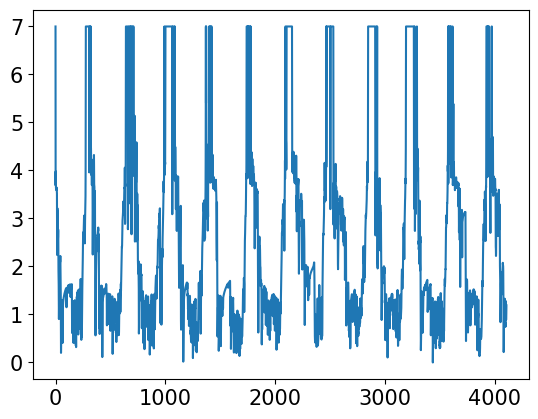

In [18]:
plt.plot(sas_Q_args)

## Train the transport model

In [17]:
# Train the model
jax.clear_caches()
transport_model_new, loss_train_mdn, loss_test_mdn = train_transport_model(
    transport_model, train_config['epochs'], mse, optim, x_train, y_train, x_test, y_test
)


2025-03-02 11:39:59,883 - INFO - The loss of step 0: 0.04700247198343277
2025-03-02 11:40:22,027 - INFO - The loss of step 1: 0.04243320971727371
2025-03-02 11:40:35,146 - INFO - The loss of step 2: 0.039076730608940125
2025-03-02 11:40:38,411 - INFO - The loss of step 3: 0.03729236498475075
2025-03-02 11:40:41,680 - INFO - The loss of step 4: 0.03623387962579727
2025-03-02 11:40:44,948 - INFO - The loss of step 5: 0.03435424342751503
2025-03-02 11:40:48,217 - INFO - The loss of step 6: 0.03149517998099327
2025-03-02 11:40:51,478 - INFO - The loss of step 7: 0.028541624546051025
2025-03-02 11:40:54,744 - INFO - The loss of step 8: 0.026592666283249855
2025-03-02 11:40:58,002 - INFO - The loss of step 9: 0.0260784849524498
100%|██████████| 10/10 [01:14<00:00,  7.42s/it]


In [71]:
# Train the model
jax.clear_caches()
transport_model_new, loss_train_mdn, loss_test_mdn = train_transport_model(
    transport_model, train_config['epochs'], mse, optim, x_train, y_train, x_test, y_test
)


2025-02-28 16:38:36,004 - INFO - The loss of step 0: 0.04700247198343277
2025-02-28 16:39:00,130 - INFO - The loss of step 1: 0.04243320971727371
2025-02-28 16:39:15,595 - INFO - The loss of step 2: 0.039076730608940125
2025-02-28 16:39:20,170 - INFO - The loss of step 3: 0.03729236498475075
2025-02-28 16:39:24,744 - INFO - The loss of step 4: 0.03623387962579727
2025-02-28 16:39:29,094 - INFO - The loss of step 5: 0.03435424342751503
2025-02-28 16:39:33,691 - INFO - The loss of step 6: 0.03149517998099327
2025-02-28 16:39:38,345 - INFO - The loss of step 7: 0.028541624546051025
2025-02-28 16:39:42,913 - INFO - The loss of step 8: 0.026592666283249855
2025-02-28 16:39:47,525 - INFO - The loss of step 9: 0.0260784849524498
2025-02-28 16:39:52,140 - INFO - The loss of step 10: 0.02559092454612255
2025-02-28 16:39:56,444 - INFO - The loss of step 11: 0.02429906092584133
2025-02-28 16:40:01,048 - INFO - The loss of step 12: 0.02324836701154709
2025-02-28 16:40:05,652 - INFO - The loss of s

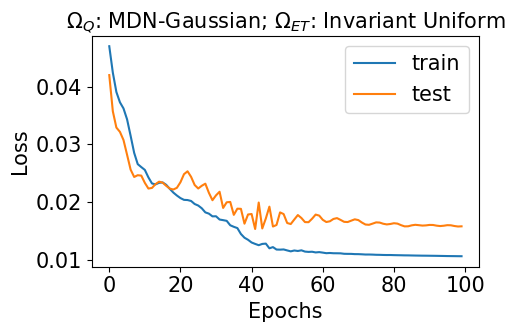

In [72]:
# Plot the loss
fig, ax = plt.subplots(1, 1, figsize=(5,3))
ax.plot(loss_train_mdn, label='train')
ax.plot(loss_test_mdn, label='test')
ax.set(xlabel='Epochs', ylabel='Loss', 
       title='$\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform')
ax.legend()


## Make predictions

In [73]:
# Run the trained model
sT, mT, mQETs, pQETs, mRs, C_Q = transport_model_new(
    J, C_J, Q, ET, sTmT_init, sas_Q_args, sas_ET_args
)
df_cut['C_Q pred'] = C_Q

# sTmT_init2 = jnp.concat([sT[:,[-1]], sTmT_init[:,1:]], axis=1)
# sT, mT, mQETs, pQETs, mRs, C_Q = transport_model_new(
#     J, C_J, Q, ET, sTmT_init2, sas_Q_args, sas_ET_args
# )
# df_cut['C_Q pred2'] = C_Q


/tmp/ipykernel_1694131/2032706935.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cut['C_Q pred'] = C_Q


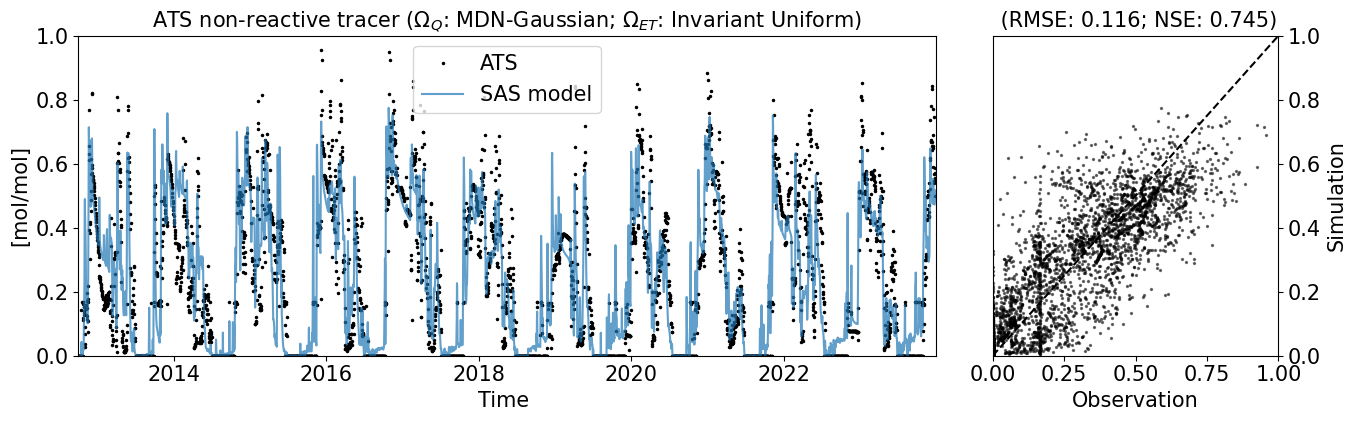

In [74]:
plot_timeseries_obs_1to1(
    obs=df_cut['C_Q'].values, sim=df_cut['C_Q pred'].values, lim=[0,1], timesteps=df_cut.index,
    varn='ATS non-reactive tracer ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)',
    units='[mol/mol]', label_sim='SAS model', label_obs='ATS'
);


In [ ]:
s, e = test_start, test_end
plot_timeseries_obs_1to1(
    obs=df_cut['C_Q'][s:e].values, sim=df_cut['C_Q pred'][s:e].values, lim=[0,1], 
    timesteps=df_cut[s:e].index,
    varn='ATS non-reactive tracer ($\Omega_Q$: MDN-Gaussian; $\Omega_{ET}$: Invariant Uniform)'
);


array([<Axes: title={'center': 'Q age distribution ()'}, ylabel='Age [Days]'>,
       <Axes: title={'center': 'ET age distribution ()'}, ylabel='Age [Days]'>],
      dtype=object)

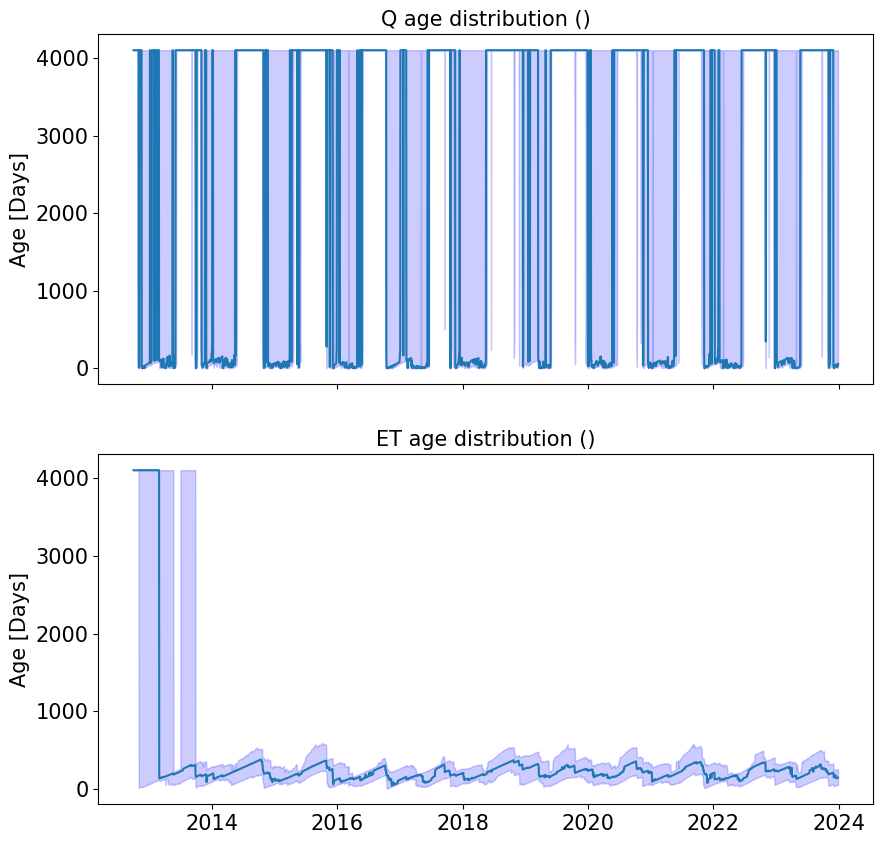

In [62]:
plot_PQET_quantile(pQETs, transport_params['transport_specs']['dt'], df_cut.index)


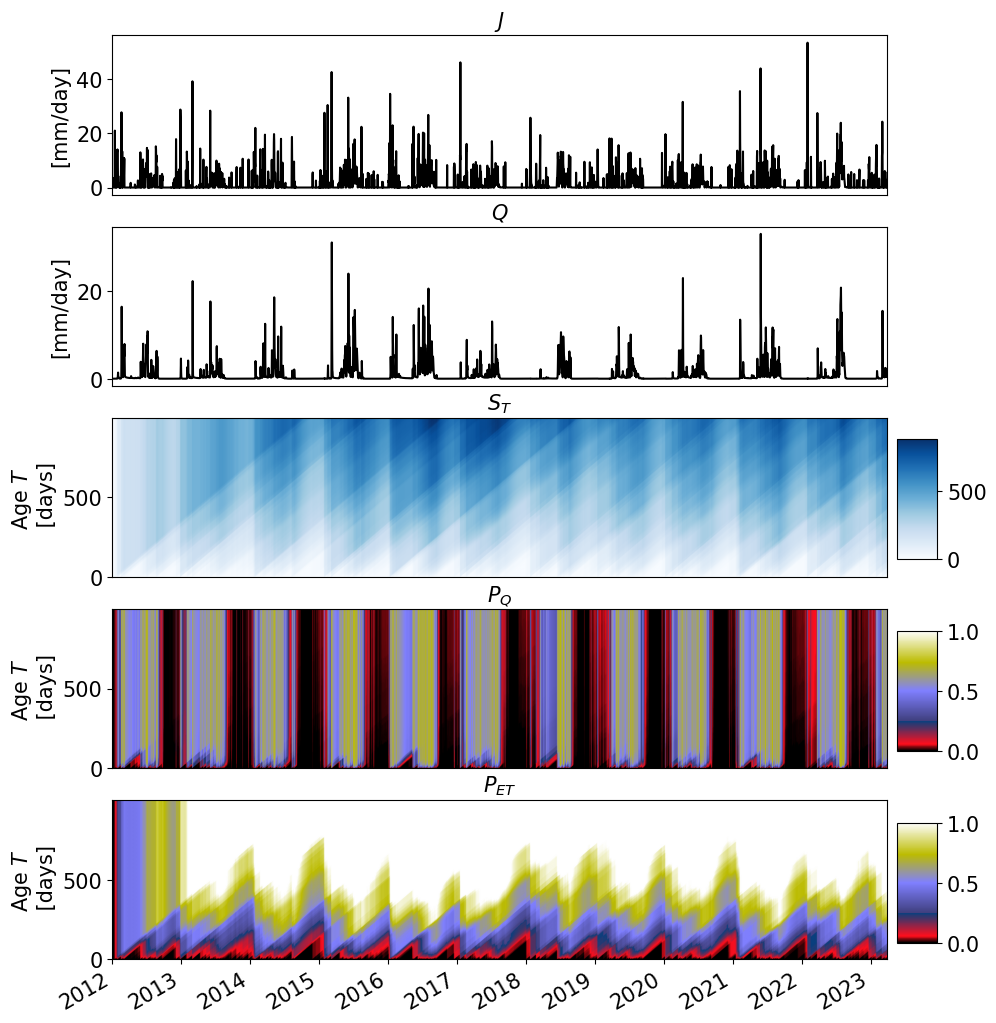

In [63]:
plot_PQET_ST(J, Q, sT, pQETs, dt, time, age_cut=1000);

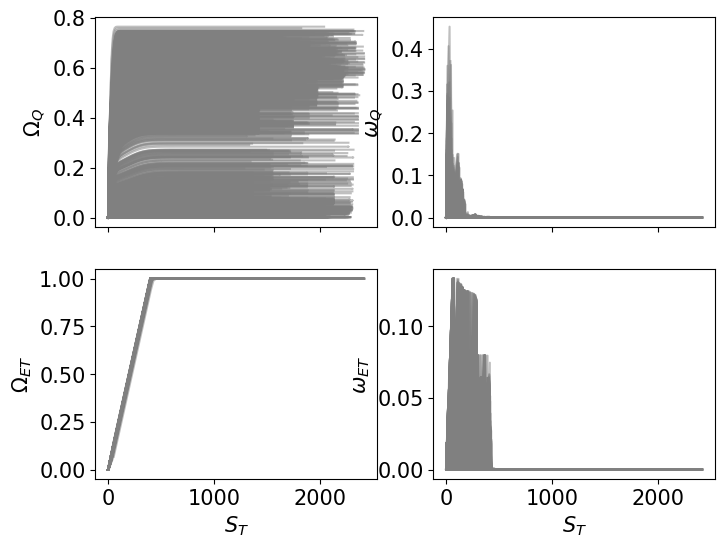

In [64]:
# Age distribution
axes = plot_PQET_ST2(sT, pQETs, dt, last_age_cut=2000, figsize=(8,6), label='')


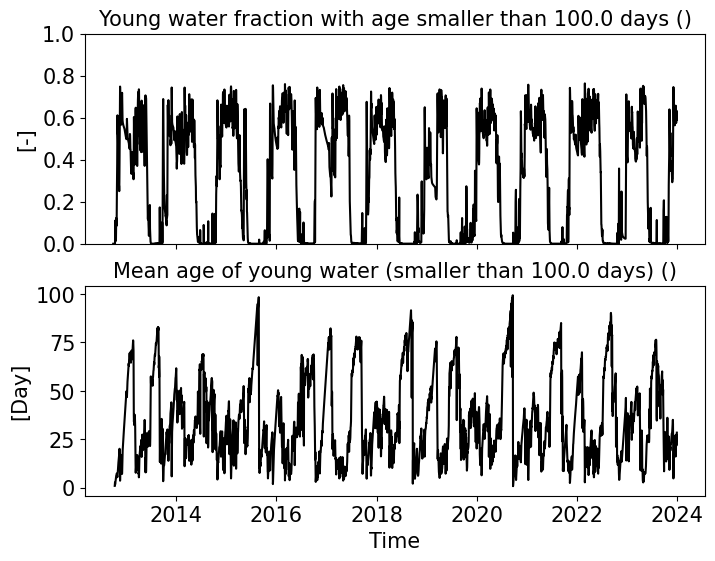

In [65]:
# Young water fraction in streamflow
plot_young_water(pQETs[...,0], time, dt=dt, cutoff_age=100);
